In [1]:
import importlib
import scraper as sc
importlib.reload(sc)
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import nltk
import ssl
import pandas as pd
import os

try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
    pass
else:
    ssl._create_default_https_context = _create_unverified_https_context

nltk.download('punkt')

plt.style.use('ggplot')

[nltk_data] Downloading package punkt to /Users/kaush/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [ ]:
nsdq = sc.nsdq_tickers("nasdaq.csv")
posts_df = sc.fetch_submissions("wallstreetbets", 100)
posts_df = sc.post_extract_tickers(posts_df, nsdq)
posts_df.head(50)

,subreddit,submission_id,author,created_utc,title,body,url,selftext,score,num_comments,is_self,upvote_ratio,permalink,content,p_mentioned
0,wallstreetbets,1nfny9x,MaranathahAmen,1757736718,$ORCL - Infinite money glitch.,rinse&repeat,https://i.redd.it/692s4wcpxuof1.jpeg,rinse&repeat,15825,356,False,0.96,https://www.reddit.com/r/wallstreetbets/commen...,$ORCL - Infinite money glitch.rinse&repeat,[ORCL]
1,wallstreetbets,1nfnb0m,doirrr,1757734640,$382-> $91k since July 7th it,Still grinding this trading style I’ve develop...,https://www.reddit.com/gallery/1nfnb0m,Still grinding this trading style I’ve develop...,3227,503,False,0.94,https://www.reddit.com/r/wallstreetbets/commen...,$382-> $91k since July 7th itStill grinding th...,[]
2,wallstreetbets,1nfm18b,alkjdasoad,1757730650,I thought September was bad for stocks,Nasdaq and S&P 500 both ripped to new highs. A...,https://www.reddit.com/r/wallstreetbets/commen...,Nasdaq and S&P 500 both ripped to new highs. A...,654,256,True,0.94,https://www.reddit.com/r/wallstreetbets/commen...,I thought September was bad for stocksNasdaq a...,[AI]
3,wallstreetbets,1nfkkd0,Athaduu,1757726239,Please accept me as your fellow regard,I went full regard and decided that fed will n...,https://i.redd.it/b2l44axj2uof1.jpeg,I went full regard and decided that fed will n...,405,211,False,0.92,https://www.reddit.com/r/wallstreetbets/commen...,Please accept me as your fellow regardI went f...,[]
4,wallstreetbets,1nfhq8k,kcazeth,1757718210,I was touched by the Winklevoss twins today,,https://i.redd.it/d9pq3ldoetof1.jpeg,,353,156,False,0.95,https://www.reddit.com/r/wallstreetbets/commen...,I was touched by the Winklevoss twins today,[]
5,wallstreetbets,1nfs0me,Altruistic-Daikon606,1757751244,My best trade yet,"Missed out on the Oracle mania, but glad to fi...",https://i.redd.it/6nlt4hmw4wof1.jpeg,"Missed out on the Oracle mania, but glad to fi...",252,38,False,0.98,https://www.reddit.com/r/wallstreetbets/commen...,My best trade yetMissed out on the Oracle mani...,[TSLA]
6,wallstreetbets,1ng5d7e,stock_casino420,1757789063,Aped into $OPEN (+110k unrealized),"Positions: 75x 1/15/27 1C, 68x 1/15/27 0.5C, -...",https://i.redd.it/rf7o7s309zof1.png,"Positions: 75x 1/15/27 1C, 68x 1/15/27 0.5C, -...",236,66,False,0.92,https://www.reddit.com/r/wallstreetbets/commen...,Aped into $OPEN (+110k unrealized)Positions: 7...,[OPEN]
7,wallstreetbets,1nfohdm,Methanar,1757738499,I'm not having fun anymore,,https://i.redd.it/7mrs0wa03vof1.png,,157,80,False,0.93,https://www.reddit.com/r/wallstreetbets/commen...,I'm not having fun anymore,[]
8,wallstreetbets,1ng2qrk,Put_Er_There_Sport,1757782981,In 5 days i gained back 9 months of losses.,That pump mid chart was April 8th-9th. Got luc...,https://www.reddit.com/gallery/1ng2qrk,That pump mid chart was April 8th-9th. Got luc...,123,35,False,0.95,https://www.reddit.com/r/wallstreetbets/commen...,In 5 days i gained back 9 months of losses.Tha...,"[OPEN, NVDA]"
9,wallstreetbets,1nfkp01,SuffiecientSapian,1757726614,Oracle goes bye bye,So turns out the pump for Oracle was all BS. S...,https://i.redd.it/36a8fk4o3uof1.jpeg,So turns out the pump for Oracle was all BS. S...,83,16,False,0.89,https://www.reddit.com/r/wallstreetbets/commen...,Oracle goes bye byeSo turns out the pump for O...,[]


In [5]:
cmts = sc.fetch_top_comments(posts_df["submission_id"][0])
cmts

,submission id,comment id,author,body,score,permalink,parent
0,1nfny9x,ndxuavs,VisualMod,\n**User Report**| | | |\n:--|:--|:--|:--\n**T...,1,https://www.reddit.com/r/wallstreetbets/commen...,t3_1nfny9x
1,1nfny9x,ndxwb9z,MilkyWayObserver,Fun fact: \n\n-Someone that bought Oracle at t...,4240,https://www.reddit.com/r/wallstreetbets/commen...,t3_1nfny9x
2,1nfny9x,ndy317d,k-mcm,Smells like Y2K. Those reciprocal investment d...,574,https://www.reddit.com/r/wallstreetbets/commen...,t3_1nfny9x
3,1nfny9x,ndy98gr,gatekeeper0x,They are really good manipulators.\n\n1. They ...,222,https://www.reddit.com/r/wallstreetbets/commen...,t3_1nfny9x
4,1nfny9x,ndxv9tg,CallMePyro,[https://x.com/Yuchenj\_UW/status/196655367186...,960,https://www.reddit.com/r/wallstreetbets/commen...,t3_1nfny9x
...,...,...,...,...,...,...,...
77,1nfny9x,ne1zv2n,te7037,$DRMA? Anyone holding this share?\n\nIt is go...,1,https://www.reddit.com/r/wallstreetbets/commen...,t3_1nfny9x
78,1nfny9x,ne2nfrz,FreakyNeighbour,Why is Sam paying Oracle?,1,https://www.reddit.com/r/wallstreetbets/commen...,t3_1nfny9x
79,1nfny9x,ndybsgf,No-Roof5569,Investors of OPEN didn’t fair well yesterday.\...,1,https://www.reddit.com/r/wallstreetbets/commen...,t3_1nfny9x
80,1nfny9x,ndxx5z1,dankbuttmuncher,You’re retarded.,-3,https://www.reddit.com/r/wallstreetbets/commen...,t3_1nfny9x


In [9]:
sample = posts_df["content"][1]
tokens = nltk.word_tokenize(sample)
tagged = nltk.pos_tag(tokens)
entities = nltk.chunk.ne_chunk(tagged)

In [10]:
from nltk.sentiment import SentimentIntensityAnalyzer
from tqdm import tqdm

sia = SentimentIntensityAnalyzer()

In [11]:
sia.polarity_scores(sample)

{'neg': 0.103, 'neu': 0.897, 'pos': 0.0, 'compound': -0.7351}

In [12]:
res = {}
for i, row in tqdm(posts_df.iterrows(), total = len(posts_df)):
    text = row["content"]
    sub_id = row["submission_id"]
    
    res[sub_id] = sia.polarity_scores(text)

100%|██████████| 22/22 [00:00<00:00, 3236.69it/s]


In [13]:
vaders = pd.DataFrame(res).T
vaders = vaders.reset_index().rename(columns={'index':'submission_id'})
vaders = vaders.merge(posts_df, how='left')
vaders

,submission_id,neg,neu,pos,compound,subreddit,author,created_utc,title,body,url,selftext,score,num_comments,is_self,upvote_ratio,permalink,content,p_mentioned
0,1nfny9x,0.000,1.000,0.000,0.0000,wallstreetbets,MaranathahAmen,1757736718,$ORCL - Infinite money glitch.,rinse&repeat,https://i.redd.it/692s4wcpxuof1.jpeg,rinse&repeat,15825,356,False,0.96,https://www.reddit.com/r/wallstreetbets/commen...,$ORCL - Infinite money glitch.rinse&repeat,[ORCL]
1,1nfnb0m,0.103,0.897,0.000,-0.7351,wallstreetbets,doirrr,1757734640,$382-> $91k since July 7th it,Still grinding this trading style I’ve develop...,https://www.reddit.com/gallery/1nfnb0m,Still grinding this trading style I’ve develop...,3227,503,False,0.94,https://www.reddit.com/r/wallstreetbets/commen...,$382-> $91k since July 7th itStill grinding th...,[]
2,1nfm18b,0.276,0.724,0.000,-0.9042,wallstreetbets,alkjdasoad,1757730650,I thought September was bad for stocks,Nasdaq and S&P 500 both ripped to new highs. A...,https://www.reddit.com/r/wallstreetbets/commen...,Nasdaq and S&P 500 both ripped to new highs. A...,654,256,True,0.94,https://www.reddit.com/r/wallstreetbets/commen...,I thought September was bad for stocksNasdaq a...,[AI]
3,1nfkkd0,0.000,0.717,0.283,0.6921,wallstreetbets,Athaduu,1757726239,Please accept me as your fellow regard,I went full regard and decided that fed will n...,https://i.redd.it/b2l44axj2uof1.jpeg,I went full regard and decided that fed will n...,405,211,False,0.92,https://www.reddit.com/r/wallstreetbets/commen...,Please accept me as your fellow regardI went f...,[]
4,1nfhq8k,0.000,1.000,0.000,0.0000,wallstreetbets,kcazeth,1757718210,I was touched by the Winklevoss twins today,,https://i.redd.it/d9pq3ldoetof1.jpeg,,353,156,False,0.95,https://www.reddit.com/r/wallstreetbets/commen...,I was touched by the Winklevoss twins today,[]
5,1nfs0me,0.000,0.591,0.409,0.8658,wallstreetbets,Altruistic-Daikon606,1757751244,My best trade yet,"Missed out on the Oracle mania, but glad to fi...",https://i.redd.it/6nlt4hmw4wof1.jpeg,"Missed out on the Oracle mania, but glad to fi...",252,38,False,0.98,https://www.reddit.com/r/wallstreetbets/commen...,My best trade yetMissed out on the Oracle mani...,[TSLA]
6,1ng5d7e,0.000,1.000,0.000,0.0000,wallstreetbets,stock_casino420,1757789063,Aped into $OPEN (+110k unrealized),"Positions: 75x 1/15/27 1C, 68x 1/15/27 0.5C, -...",https://i.redd.it/rf7o7s309zof1.png,"Positions: 75x 1/15/27 1C, 68x 1/15/27 0.5C, -...",236,66,False,0.92,https://www.reddit.com/r/wallstreetbets/commen...,Aped into $OPEN (+110k unrealized)Positions: 7...,[OPEN]
7,1nfohdm,0.403,0.597,0.000,-0.4023,wallstreetbets,Methanar,1757738499,I'm not having fun anymore,,https://i.redd.it/7mrs0wa03vof1.png,,157,80,False,0.93,https://www.reddit.com/r/wallstreetbets/commen...,I'm not having fun anymore,[]
8,1ng2qrk,0.085,0.793,0.122,0.8673,wallstreetbets,Put_Er_There_Sport,1757782981,In 5 days i gained back 9 months of losses.,That pump mid chart was April 8th-9th. Got luc...,https://www.reddit.com/gallery/1ng2qrk,That pump mid chart was April 8th-9th. Got luc...,123,35,False,0.95,https://www.reddit.com/r/wallstreetbets/commen...,In 5 days i gained back 9 months of losses.Tha...,"[OPEN, NVDA]"
9,1nfkp01,0.000,1.000,0.000,0.0000,wallstreetbets,SuffiecientSapian,1757726614,Oracle goes bye bye,So turns out the pump for Oracle was all BS. S...,https://i.redd.it/36a8fk4o3uof1.jpeg,So turns out the pump for Oracle was all BS. S...,83,16,False,0.89,https://www.reddit.com/r/wallstreetbets/commen...,Oracle goes bye byeSo turns out the pump for O...,[]


In [14]:
cmt_scores = {}
for i, row in tqdm(posts_df.iterrows(), total=len(posts_df)):
    cmts_df = sc.fetch_top_comments(row["submission_id"])
    if cmts_df.empty:
        avg_compound = None
    else:
        cmts_df["compound"] = cmts_df["body"].apply(lambda x: sia.polarity_scores(x)["compound"])
        avg_compound = cmts_df["compound"].mean()
    cmt_scores[row["submission_id"]] = avg_compound

comment_scores_df = pd.DataFrame.from_dict(cmt_scores, orient = 'index', columns = ["c_compound"])
comment_scores_df = comment_scores_df.reset_index().rename(columns = {'index' : 'submission_id'})
merged = vaders.merge(comment_scores_df, on='submission_id', how='right')

100%|██████████| 22/22 [00:19<00:00,  1.14it/s]


In [16]:
merged

,submission_id,neg,neu,pos,compound,subreddit,author,created_utc,title,body,url,selftext,score,num_comments,is_self,upvote_ratio,permalink,content,p_mentioned,c_compound
0,1nf1lyq,0.000,0.575,0.425,0.5719,wallstreetbets,tortoisepump,1757679353,2025 trading (so far),Practice makes perfect.,https://v.redd.it/2ulkbtl07qof1,Practice makes perfect.,4422,90,False,0.97,https://www.reddit.com/r/wallstreetbets/commen...,2025 trading (so far)Practice makes perfect.,[],0.141344
1,1neunqa,0.000,1.000,0.000,0.0000,wallstreetbets,Suitable-Cucumber-77,1757654035,Long $OPEN,Shorts are REKT,https://i.redd.it/796vlonu3oof1.jpeg,Shorts are REKT,3391,287,False,0.96,https://www.reddit.com/r/wallstreetbets/commen...,Long $OPENShorts are REKT,[],0.043679
2,1new9bz,0.054,0.784,0.162,0.7696,wallstreetbets,Sufficient_Sport5251,1757660023,Real talk. Is the market rallying too much on ...,Like I get it’s cool that it’s going to be the...,https://www.reddit.com/r/wallstreetbets/commen...,Like I get it’s cool that it’s going to be the...,1310,484,True,0.94,https://www.reddit.com/r/wallstreetbets/commen...,Real talk. Is the market rallying too much on ...,[],-0.037131
3,1nez5dv,0.085,0.915,0.000,-0.2411,wallstreetbets,wsbapp,1757671345,"Daily Discussion Thread for September 12, 2025",This post contains content not supported on ol...,https://www.reddit.com/r/wallstreetbets/commen...,This post contains content not supported on ol...,189,10637,True,0.94,https://www.reddit.com/r/wallstreetbets/commen...,"Daily Discussion Thread for September 12, 2025...",[],0.002260
4,1nfee1a,0.072,0.870,0.058,-0.1779,wallstreetbets,rebornyc,1757710035,TSLA saved my account from $3k → $21k 💎🙌,"Was down bad, thought my account was toast. \...",https://v.redd.it/i6khw6zcqsof1,"Was down bad, thought my account was toast. \...",194,64,False,0.84,https://www.reddit.com/r/wallstreetbets/commen...,TSLA saved my account from $3k → $21k 💎🙌Was do...,[TSLA],0.240389
5,1newcu1,0.037,0.884,0.079,0.5423,wallstreetbets,i-love-you-sm,1757660411,TLRY,Rock solid balance sheet\n\nNet neutral cash/d...,https://i.redd.it/0rqsr3atmoof1.jpeg,Rock solid balance sheet\n\nNet neutral cash/d...,183,92,False,0.89,https://www.reddit.com/r/wallstreetbets/commen...,TLRYRock solid balance sheet\n\nNet neutral ca...,"[DEA, HHS]",0.157339
6,1nezf2p,0.000,1.000,0.000,0.0000,wallstreetbets,LCS-B18,1757672327,$LDI,"Few days ago, someone called me europoor but I...",https://i.redd.it/jga0f7t8mpof1.jpeg,"Few days ago, someone called me europoor but I...",186,52,False,0.93,https://www.reddit.com/r/wallstreetbets/commen...,"$LDIFew days ago, someone called me europoor b...",[],0.213079
7,1nf66zm,0.122,0.878,0.000,-0.3595,wallstreetbets,Critical_Sun6646,1757690754,"$LDI - I'm in, Let's Go!","Switched from OPEN to LDI, with rate cuts comi...",https://www.reddit.com/r/wallstreetbets/commen...,"Switched from OPEN to LDI, with rate cuts comi...",171,119,True,0.91,https://www.reddit.com/r/wallstreetbets/commen...,"$LDI - I'm in, Let's Go!Switched from OPEN to ...","[LDI, OPEN]",0.151158
8,1nesof3,0.000,0.809,0.191,0.8402,wallstreetbets,gsk694,1757647431,$OPEN it up,Had a total of 72 LEAPs in between the two ret...,https://www.reddit.com/gallery/1nesof3,Had a total of 72 LEAPs in between the two ret...,159,34,False,0.90,https://www.reddit.com/r/wallstreetbets/commen...,$OPEN it upHad a total of 72 LEAPs in between ...,[OPEN],0.057233
9,1nfhq8k,0.000,1.000,0.000,0.0000,wallstreetbets,kcazeth,1757718210,I was touched by the Winklevoss twins today,,https://i.redd.it/d9pq3ldoetof1.jpeg,,165,102,False,0.93,https://www.reddit.com/r/wallstreetbets/commen...,I was touched by the Winklevoss twins today,[],0.150763


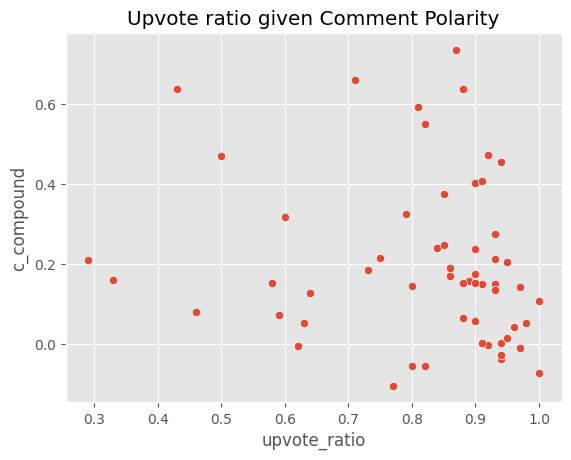

In [17]:
axis = sns.scatterplot(data = merged, x = 'upvote_ratio', y = 'c_compound')
axis.set_title("Upvote ratio given Comment Polarity")
plt.show()

In [38]:
from huggingface_hub import InferenceClient
from dotenv import load_dotenv

load_dotenv("/Users/kaush/Documents/Hotstox/credentials.env")
hf_token = os.getenv("HF_TOKEN")

client = InferenceClient(api_key = hf_token)

result = client.text_classification(merged["content"][0], model="ProsusAI/finbert")

print(result)



[TextClassificationOutputElement(label='neutral', score=0.5661244988441467), TextClassificationOutputElement(label='positive', score=0.42217016220092773), TextClassificationOutputElement(label='negative', score=0.011705323122441769)]
